# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [1]:
from pathlib import Path

# 1. Define paths and limits
data_dir = Path('C://Users//revan//Downloads//archive//Geolife Trajectories 1.3//Data')
output_filename = 'dataset.csv'

USER_LIMIT = 100
FILE_LIMIT_PER_USER = 5



users_processed = 0
total_files_processed = 0

print(f"Starting merge: target {USER_LIMIT} users, {FILE_LIMIT_PER_USER} files each...")

with open(output_filename, 'w') as outfile:


    # Sort the directories alphabetically so we start exactly at '000'
    user_dirs = sorted([d for d in data_dir.iterdir() if d.is_dir() and d.name.isdigit()])

    for user_dir in user_dirs:
        # Stop if we hit 100 users
        if users_processed >= USER_LIMIT:
            break

        traj_dir = user_dir / 'Trajectory'

        if traj_dir.exists():
            files_for_this_user = 0

            # Sort files by name/time to grab the first 5 chronologically
            plt_files = sorted(list(traj_dir.glob('*.plt')))

            for plt_file in plt_files:
                # Stop if we hit 5 files for this specific user
                if files_for_this_user >= FILE_LIMIT_PER_USER:
                    break

                with open(plt_file, 'r') as infile:
                    # Skip the 6 header lines
                    for _ in range(6):
                        next(infile, None)

                    # Write the data
                    for line in infile:
                        outfile.write(line)

                files_for_this_user += 1
                total_files_processed += 1

        users_processed += 1

print(f"Success! Merged {total_files_processed} files from {users_processed} users into '{output_filename}'.")


Starting merge: target 100 users, 5 files each...
Success! Merged 484 files from 100 users into 'dataset.csv'.


In [2]:
for data in data_dir.iterdir():
    print(data)

C:\Users\revan\Downloads\archive\Geolife Trajectories 1.3\Data\000
C:\Users\revan\Downloads\archive\Geolife Trajectories 1.3\Data\001
C:\Users\revan\Downloads\archive\Geolife Trajectories 1.3\Data\002
C:\Users\revan\Downloads\archive\Geolife Trajectories 1.3\Data\003
C:\Users\revan\Downloads\archive\Geolife Trajectories 1.3\Data\004
C:\Users\revan\Downloads\archive\Geolife Trajectories 1.3\Data\005
C:\Users\revan\Downloads\archive\Geolife Trajectories 1.3\Data\006
C:\Users\revan\Downloads\archive\Geolife Trajectories 1.3\Data\007
C:\Users\revan\Downloads\archive\Geolife Trajectories 1.3\Data\008
C:\Users\revan\Downloads\archive\Geolife Trajectories 1.3\Data\009
C:\Users\revan\Downloads\archive\Geolife Trajectories 1.3\Data\010
C:\Users\revan\Downloads\archive\Geolife Trajectories 1.3\Data\011
C:\Users\revan\Downloads\archive\Geolife Trajectories 1.3\Data\012
C:\Users\revan\Downloads\archive\Geolife Trajectories 1.3\Data\013
C:\Users\revan\Downloads\archive\Geolife Trajectories 1.3\Data

In [3]:
from xgboost import XGBRegressor
import pandas as pd
import numpy as np
import matplotlib as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [4]:
df=pd.read_csv("C://Users//revan//PycharmProjects//JupyterProject3//dataset.csv")
df.head()


,39.984702,116.318417,0,492,39744.1201851852,2008-10-23,02:53:04
0,39.984683,116.318450,0,492.0,39744.120255,2008-10-23,02:53:10
1,39.984686,116.318417,0,492.0,39744.120313,2008-10-23,02:53:15
2,39.984688,116.318385,0,492.0,39744.120370,2008-10-23,02:53:20
3,39.984655,116.318263,0,492.0,39744.120428,2008-10-23,02:53:25
4,39.984611,116.318026,0,493.0,39744.120486,2008-10-23,02:53:30


In [5]:
print(df.isnull())

        39.984702  116.318417      0    492  39744.1201851852  2008-10-23  \
0           False       False  False  False             False       False   
1           False       False  False  False             False       False   
2           False       False  False  False             False       False   
3           False       False  False  False             False       False   
4           False       False  False  False             False       False   
...           ...         ...    ...    ...               ...         ...   
578320      False       False  False  False             False       False   
578321      False       False  False  False             False       False   
578322      False       False  False  False             False       False   
578323      False       False  False  False             False       False   
578324      False       False  False  False             False       False   

        02:53:04  
0          False  
1          False  
2          False  

In [6]:
df.columns=["latitude","longitude","null","elevation","notusefull","date","time"]
df.head()

,latitude,longitude,null,elevation,notusefull,date,time
0,39.984683,116.318450,0,492.0,39744.120255,2008-10-23,02:53:10
1,39.984686,116.318417,0,492.0,39744.120313,2008-10-23,02:53:15
2,39.984688,116.318385,0,492.0,39744.120370,2008-10-23,02:53:20
3,39.984655,116.318263,0,492.0,39744.120428,2008-10-23,02:53:25
4,39.984611,116.318026,0,493.0,39744.120486,2008-10-23,02:53:30


In [7]:
df.drop(["null","notusefull"],axis=1,inplace=True)
df.head()

,latitude,longitude,elevation,date,time
0,39.984683,116.318450,492.0,2008-10-23,02:53:10
1,39.984686,116.318417,492.0,2008-10-23,02:53:15
2,39.984688,116.318385,492.0,2008-10-23,02:53:20
3,39.984655,116.318263,492.0,2008-10-23,02:53:25
4,39.984611,116.318026,493.0,2008-10-23,02:53:30


In [8]:
df.head()

,latitude,longitude,elevation,date,time
0,39.984683,116.318450,492.0,2008-10-23,02:53:10
1,39.984686,116.318417,492.0,2008-10-23,02:53:15
2,39.984688,116.318385,492.0,2008-10-23,02:53:20
3,39.984655,116.318263,492.0,2008-10-23,02:53:25
4,39.984611,116.318026,493.0,2008-10-23,02:53:30


In [9]:
df.head()

,latitude,longitude,elevation,date,time
0,39.984683,116.318450,492.0,2008-10-23,02:53:10
1,39.984686,116.318417,492.0,2008-10-23,02:53:15
2,39.984688,116.318385,492.0,2008-10-23,02:53:20
3,39.984655,116.318263,492.0,2008-10-23,02:53:25
4,39.984611,116.318026,493.0,2008-10-23,02:53:30


In [10]:
import pandas as pd
import requests
import numpy as np

# --
df['date'] = pd.to_datetime(df['date']).dt.strftime('%Y-%m-%d')
df['hour'] = pd.to_datetime(df['time'], format='%H:%M:%S').dt.hour

# --- STEP 2: Vectorized API Call (The Speed Fix) ---
# Instead of looping, we get the start and end of your entire project
start_date = df['date'].min()
end_date = df['date'].max()

# Use the average center of your GPS points for the weather location
# (Beijing is clustered, so a central point works perfectly for city-wide weather)
lat_center = df['latitude'].mean()
lon_center = df['longitude'].mean()

print(f"Fetching entire weather range from {start_date} to {end_date}...")

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": lat_center,
    "longitude": lon_center,
    "start_date": start_date,
    "end_date": end_date,
    "hourly": "temperature_2m",
    "timezone": "auto"
}

response = requests.get(url, params=params)
data = response.json()

if 'hourly' in data:
    # --- STEP 3: Vectorized Data Wrangling ---
    # Create the weather dataframe instantly from the JSON lists
    weather_df = pd.DataFrame({
        'full_time': data['hourly']['time'],
        'temperature_c': data['hourly']['temperature_2m']
    })

    # Split the API's '2007-10-23T00:00' into 'date' and 'hour' columns
    weather_df['date'] = weather_df['full_time'].str[:10]
    weather_df['hour'] = weather_df['full_time'].str[11:13].astype(int)

    # Drop the temporary helper column
    weather_df = weather_df.drop(columns=['full_time'])

    # --- STEP 4: The Merge Fix ---
    # We use 'left' merge. If temperature_c was missing before, this WILL add it.
    # We must ensure no old temperature_c column exists to avoid temperature_c_x / temperature_c_y
    if 'temperature_c' in df.columns:
        df = df.drop(columns=['temperature_c'])

    df = pd.merge(df, weather_df, on=['date', 'hour'], how='left')

    # Final check: Fill any small gaps (missing hours) with the nearest temperature
    df['temperature_c'] = df['temperature_c'].ffill().bfill()

    print("Success! Weather data merged.")
else:
    print("Error: Could not retrieve data. Check API limits or Date Range.")

# --- STEP 5: Save and Preview ---
print(df[['date', 'time', 'hour', 'temperature_c']].head())


Fetching entire weather range from 2007-04-12 to 2012-01-06...
Success! Weather data merged.
         date      time  hour  temperature_c
0  2008-10-23  02:53:10     2           11.6
1  2008-10-23  02:53:15     2           11.6
2  2008-10-23  02:53:20     2           11.6
3  2008-10-23  02:53:25     2           11.6
4  2008-10-23  02:53:30     2           11.6


In [11]:
df.head()

,latitude,longitude,elevation,date,time,hour,temperature_c
0,39.984683,116.318450,492.0,2008-10-23,02:53:10,2,11.6
1,39.984686,116.318417,492.0,2008-10-23,02:53:15,2,11.6
2,39.984688,116.318385,492.0,2008-10-23,02:53:20,2,11.6
3,39.984655,116.318263,492.0,2008-10-23,02:53:25,2,11.6
4,39.984611,116.318026,493.0,2008-10-23,02:53:30,2,11.6


In [12]:
#group_size column
unique_dates = df['date'].unique()
np.random.seed(42)
random_group_sizes = np.random.randint(1, 6, size=len(unique_dates))
date_to_group_size = dict(zip(unique_dates, random_group_sizes))

# 4. The Magic Map: instantly apply that group size to every single row matching that date
df['group_size'] = df['date'].map(date_to_group_size)
print("Group sizes assigned!")
print(df[['date', 'time',  'group_size']].head(10))


df.to_csv('final_fatigue_predictor.csv', index=False)

Group sizes assigned!
         date      time  group_size
0  2008-10-23  02:53:10           4
1  2008-10-23  02:53:15           4
2  2008-10-23  02:53:20           4
3  2008-10-23  02:53:25           4
4  2008-10-23  02:53:30           4
5  2008-10-23  02:53:35           4
6  2008-10-23  02:53:40           4
7  2008-10-23  02:53:45           4
8  2008-10-23  02:53:50           4
9  2008-10-23  02:53:55           4


In [13]:
df.head()

,latitude,longitude,elevation,date,time,hour,temperature_c,group_size
0,39.984683,116.318450,492.0,2008-10-23,02:53:10,2,11.6,4
1,39.984686,116.318417,492.0,2008-10-23,02:53:15,2,11.6,4
2,39.984688,116.318385,492.0,2008-10-23,02:53:20,2,11.6,4
3,39.984655,116.318263,492.0,2008-10-23,02:53:25,2,11.6,4
4,39.984611,116.318026,493.0,2008-10-23,02:53:30,2,11.6,4


In [14]:

df['lat_prev'] = df.groupby('date')['latitude'].shift(1)
df['lon_prev'] = df.groupby('date')['longitude'].shift(1)

# 1. Define the fast math function
def haversine_np(lat1, lon1, lat2, lon2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371 * c # Result in Kilometers

# 2. Fast Calculation (Replaces your slow .apply)
df['dist_delta_km'] = haversine_np(
    df['latitude'], df['longitude'],
    df['lat_prev'].fillna(df['latitude']),
    df['lon_prev'].fillna(df['longitude'])
)

# 3. Apply Jitter Filter (Vectorized)
df.loc[df['dist_delta_km'] < 0.002, 'dist_delta_km'] = 0.0
df = df.drop(columns=['lat_prev', 'lon_prev'])
# 4. Total Distance
df['total distance'] = df.groupby('date')['dist_delta_km'].cumsum()

In [15]:
df.head()

,latitude,longitude,elevation,date,time,hour,temperature_c,group_size,dist_delta_km,total distance
0,39.984683,116.318450,492.0,2008-10-23,02:53:10,2,11.6,4,0.000000,0.000000
1,39.984686,116.318417,492.0,2008-10-23,02:53:15,2,11.6,4,0.002831,0.002831
2,39.984688,116.318385,492.0,2008-10-23,02:53:20,2,11.6,4,0.002735,0.005567
3,39.984655,116.318263,492.0,2008-10-23,02:53:25,2,11.6,4,0.011023,0.016590
4,39.984611,116.318026,493.0,2008-10-23,02:53:30,2,11.6,4,0.020777,0.037366


In [16]:


df['elevation'] = df['elevation'].replace(-777, np.nan)
df['elevation'] = df.groupby('date')['elevation'].ffill()
df['elevation'] = df.groupby('date')['elevation'].bfill()
# 1. Calculate the change in altitude from the previous point

df['elev_delta_feet'] = df.groupby('date')['elevation'].diff().fillna(0)

df['elev_gain_step_feet'] = df['elev_delta_feet'].clip(lower=0)

# 3. Convert to Meters
# Standard conversion: 1 foot = 0.3048 meters
df['elev_gain_step_m'] = df['elev_gain_step_feet'] * 0.3048

# 4. Calculate the Running Total (Cumulative Sum)
df['total_elevation_gain'] = df.groupby('date')['elev_gain_step_m'].cumsum()

# 5. Cleanup temporary columns
df = df.drop(columns=['elev_delta_feet', 'elev_gain_step_feet', 'elev_gain_step_m'])

print("Elevation gain calculated in meters!")
print(df[['date', 'time', 'elevation', 'total_elevation_gain']].tail(10))

Elevation gain calculated in meters!
              date      time   elevation  total_elevation_gain
578315  2007-12-30  11:06:30  200.131234                  56.0
578316  2007-12-30  11:07:04  200.131234                  56.0
578317  2007-12-30  11:07:58  200.131234                  56.0
578318  2007-12-30  11:08:55  200.131234                  56.0
578319  2007-12-30  11:09:44  200.131234                  56.0
578320  2007-12-30  11:11:07  200.131234                  56.0
578321  2007-12-30  11:14:24  131.233596                  56.0
578322  2007-12-30  11:15:54  134.514436                  57.0
578323  2007-12-30  11:16:49  134.514436                  57.0
578324  2007-12-30  11:17:38  134.514436                  57.0


In [17]:
df.head()

,latitude,longitude,elevation,date,time,hour,temperature_c,group_size,dist_delta_km,total distance,total_elevation_gain
0,39.984683,116.318450,492.0,2008-10-23,02:53:10,2,11.6,4,0.000000,0.000000,0.0000
1,39.984686,116.318417,492.0,2008-10-23,02:53:15,2,11.6,4,0.002831,0.002831,0.0000
2,39.984688,116.318385,492.0,2008-10-23,02:53:20,2,11.6,4,0.002735,0.005567,0.0000
3,39.984655,116.318263,492.0,2008-10-23,02:53:25,2,11.6,4,0.011023,0.016590,0.0000
4,39.984611,116.318026,493.0,2008-10-23,02:53:30,2,11.6,4,0.020777,0.037366,0.3048


In [18]:



df['ED'] = df['total distance'] + (df['total_elevation_gain'] / 120)


base_score = np.minimum(df['ED'] * 2.5, 100)


t = df['temperature_c']
t_conditions = [
    (t < 10),
    (t >= 10) & (t <= 20),
    (t > 20)
]
t_choices = [
    1 + 0.010 * (10 - t),
    1.000,                 # Optimal zone
    1 + 0.013 * (t - 20)   # Heat penalty (Galloway & Maughan)
]
df['T_factor'] = np.select(t_conditions, t_choices, default=1.0)


n = df['group_size']
g_conditions = [
    (n <= 4),
    (n > 4) & (n <= 12),
    (n > 12)
]
g_choices = [
    1.000,
    1 + 0.05 * (n - 4),
    1.45
]
df['G_factor'] = np.select(g_conditions, g_choices, default=1.0)

# 5. Calculate Final Fatigue Index (FI)

df['fatigue_index'] = base_score * df['T_factor'] * df['G_factor']
df['fatigue_index'] = np.minimum(df['fatigue_index'], 100)


df = df.drop(columns=['ED', 'T_factor', 'G_factor'])



In [19]:
df.head()

,latitude,longitude,elevation,date,time,hour,temperature_c,group_size,dist_delta_km,total distance,total_elevation_gain,fatigue_index
0,39.984683,116.318450,492.0,2008-10-23,02:53:10,2,11.6,4,0.000000,0.000000,0.0000,0.000000
1,39.984686,116.318417,492.0,2008-10-23,02:53:15,2,11.6,4,0.002831,0.002831,0.0000,0.007078
2,39.984688,116.318385,492.0,2008-10-23,02:53:20,2,11.6,4,0.002735,0.005567,0.0000,0.013917
3,39.984655,116.318263,492.0,2008-10-23,02:53:25,2,11.6,4,0.011023,0.016590,0.0000,0.041474
4,39.984611,116.318026,493.0,2008-10-23,02:53:30,2,11.6,4,0.020777,0.037366,0.3048,0.099766


In [20]:
df.describe()

,latitude,longitude,elevation,hour,temperature_c,group_size,dist_delta_km,total distance,total_elevation_gain,fatigue_index
count,578325.000000,578325.000000,578325.000000,578325.000000,578325.000000,578325.000000,578325.000000,578325.000000,578325.000000,578325.000000
mean,39.168808,116.997486,261.182320,9.237892,8.865062,3.054431,0.058344,247.807443,2960.706119,77.314688
std,3.899422,2.277064,504.109815,5.928463,12.382832,1.341110,6.238675,459.098722,3697.103031,34.410062
min,22.562920,111.495203,-17582.000000,0.000000,-11.500000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,39.906465,116.311349,75.459318,5.000000,-3.100000,2.000000,0.003046,13.795783,445.068960,51.925841
50%,39.972339,116.334125,150.462425,9.000000,9.400000,3.000000,0.008326,53.093497,1633.728000,100.000000
75%,39.999680,116.448123,252.600000,13.000000,19.400000,4.000000,0.018408,219.867946,4040.733600,100.000000
max,46.624220,129.603960,42670.600000,23.000000,35.700000,5.000000,1976.069793,3979.330976,20398.435200,100.000000


In [21]:
from sklearn.model_selection import train_test_split
y=df["fatigue_index"]
X=df.drop(columns=['fatigue_index',"date","time"])
X_train,X_temp,y_train,y_temp=train_test_split(X,y,test_size=0.3)
X_val,X_test,y_val,y_test=train_test_split(X_temp,y_temp,test_size=0.3)


In [31]:
from xgboost import XGBRegressor
import xgboost as xgb
from sklearn.metrics import root_mean_squared_error
model=XGBRegressor(n_estimators=200,learning_rate=0.1,n_jobs=2,early_stopping_rounds=20,eval_metric='rmse')
model.fit(X_train,y_train,eval_set=[(X_val,y_val)],verbose=20)
y_pred=model.predict(X_test)
rmse=root_mean_squared_error(y_test,y_pred)



[0]	validation_0-rmse:31.06960
[20]	validation_0-rmse:3.91940
[40]	validation_0-rmse:0.73574
[60]	validation_0-rmse:0.45782
[80]	validation_0-rmse:0.39957
[100]	validation_0-rmse:0.36709
[120]	validation_0-rmse:0.34425
[140]	validation_0-rmse:0.32810
[160]	validation_0-rmse:0.31101
[180]	validation_0-rmse:0.29627
[199]	validation_0-rmse:0.28753


In [32]:
print(f"the root mean square for test set is {rmse}")


the root mean square for test set is 0.28736761812596057


Axes(0.125,0.11;0.775x0.77)


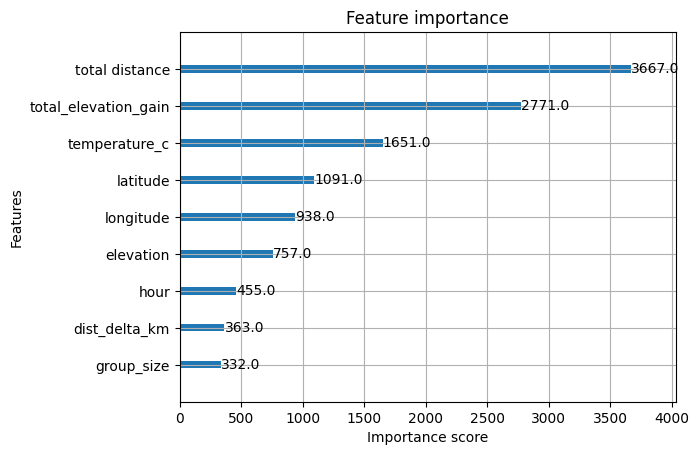

In [33]:
import matplotlib.pyplot as plt
importance=xgb.plot_importance(model)
print(importance)

In [112]:
print(f"the best rmse score of the model {model.best_score}")

print(f"the best iteration {model.best_iteration}")

the best rmse score of the model 0.28286926122940914
the best iteration 199
